# Where's My Money: stuck-funds analysis

This notebook answers the business questions behind the triage console with **SQL (SQLite)** and **pandas**.

The data is a deterministic synthetic snapshot of 362 open transfers, exported from the app's TypeScript model (`npm run export:data`). It's normalized into the systems where a transfer's status actually lives:

| Table | Source system |
|---|---|
| `transfers` | the app |
| `partner_events` | payment partner webhooks |
| `ledger_entries` | internal ledger |
| `compliance_reviews` | compliance case tool |
| `triage` | output of the rules engine |

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pipeline

con = pipeline.connect()   # builds an in-memory SQLite DB from schema.sql + data/*.csv
pd.set_option("display.max_colwidth", 70)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
[q.key for q in pipeline.load_queries()]

['01_snapshot_kpis',
 '02_reason_ranking',
 '03_owner_workload',
 '04_sla_by_rail',
 '05_reconcile_arrived_not_posted',
 '06_silent_compliance_holds',
 '07_country_exposure']

## 1. How big is the problem?

In [2]:
pipeline.run(con, "01")

,open_transfers,stuck,stuck_usd,pct_stuck_never_told,pct_past_sla
0,362,221,191638.0,76.0,54.7


About three quarters of stuck transfers have **no explanation sent to the customer**. That gap, more than the delays themselves, is what drives "where's my money" tickets.

## 2. Which reasons should be fixed first?
Ranked by items × median wait. The median is computed in SQL with window functions, because SQLite has no `MEDIAN()`.

In [3]:
rank = pipeline.run(con, "02")
rank

,reason,owner,items,usd_stuck,median_age_h,pct_past_sla,priority_score
0,"Under review, customer not told",Compliance,41,26856.0,123.3,90.0,5055.0
1,Sent into a rail under maintenance,Ops,31,32239.0,108.1,90.0,3351.0
2,Waiting on customer document,Customer,29,19770.0,110.2,86.0,3196.0
3,"Arrived, can't match to a customer",Ops,26,35555.0,122.0,92.0,3173.0
4,Returned by bank,Customer,24,19231.0,75.8,88.0,1820.0
5,"At partner, past SLA",Ops,34,26095.0,45.6,100.0,1552.0
6,"Arrived, not posted",Engineering,19,23609.0,60.2,79.0,1144.0
7,Crypto sent on the wrong network,Engineering,11,4830.0,63.1,100.0,694.0
8,No rule matched,Investigate,6,3453.0,11.5,50.0,69.0


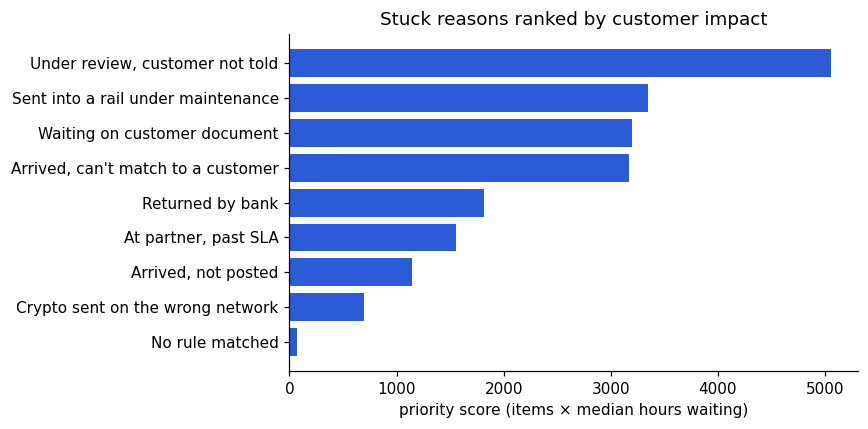

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
r = rank.sort_values("priority_score")
ax.barh(r.reason, r.priority_score, color="#2b5bd7")
ax.set_xlabel("priority score (items × median hours waiting)")
ax.set_title("Stuck reasons ranked by customer impact")
plt.tight_layout()
fig.savefig("figures/reason_ranking.png")

## 3. Who owns the next move?

In [5]:
pipeline.run(con, "03")

,owner,items,usd,past_sla,reasons
0,Ops,91,93889.0,86,"Sent into a rail under maintenance,At partner, past SLA,Arrived, c..."
1,Customer,53,39001.0,46,"Waiting on customer document,Returned by bank"
2,Engineering,30,28439.0,26,"Crypto sent on the wrong network,Arrived, not posted"
3,Compliance,41,26856.0,37,"Under review, customer not told"
4,Investigate,6,3453.0,3,No rule matched


## 4. Which rails breach their SLA?

,rail,sla_hours,open_items,past_sla,breach_rate_pct,avg_age_vs_sla
0,Cash pickup,24.0,56,38,67.9,3.10
1,US wire in,24.0,63,40,63.5,2.91
2,Crypto in,1.0,43,27,62.8,44.76
3,MXN SPEI in,1.0,49,27,55.1,52.74
4,Bank payout,48.0,41,22,53.7,1.94
5,EUR SEPA in,24.0,63,32,50.8,2.24
6,US ACH in,72.0,47,12,25.5,0.93


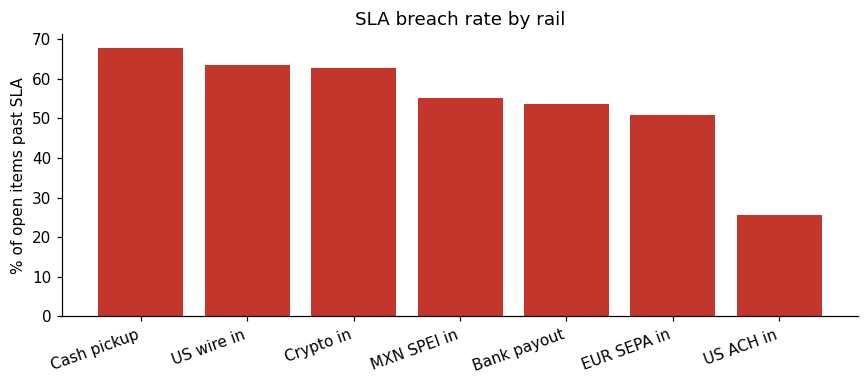

In [6]:
rails = pipeline.run(con, "04")
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(rails.rail, rails.breach_rate_pct, color="#c2362b")
ax.set_ylabel("% of open items past SLA")
ax.set_title("SLA breach rate by rail")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig("figures/sla_by_rail.png")
rails

## 5. Reconciliation: arrived, not posted

This is the highest-risk failure mode. The partner confirmed settlement with a matching reference, but the ledger never credited the customer. Nothing failed, so nothing alerted.

This query finds these transfers **from the raw source tables with joins alone**, independent of the app's rules engine. The test suite asserts that both methods return the same 19 transfers.

In [7]:
desync = pipeline.run(con, "05")
print(f"{len(desync)} transfers, ${desync.amount_usd.sum():,.0f} settled but not in customer balances")
desync.head(10)

19 transfers, $23,609 settled but not in customer balances


,transfer_id,customer_id,rail,amount_usd,hours_since_settled
0,TX-10337,C6345,US wire in,2958.0,110.8
1,TX-10338,C6661,US wire in,3498.0,103.8
2,TX-10330,C6006,US wire in,2372.0,99.2
3,TX-10336,C8475,MXN SPEI in,418.0,93.6
4,TX-10341,C3007,MXN SPEI in,295.0,89.7
5,TX-10329,C3403,MXN SPEI in,1088.0,70.5
6,TX-10327,C3963,EUR SEPA in,175.0,66.9
7,TX-10343,C10393,EUR SEPA in,973.0,65.9
8,TX-10326,C3778,US ACH in,762.0,51.8
9,TX-10328,C9583,US ACH in,746.0,51.1


## 6. Silent compliance holds, by how long the customer has been waiting

In [8]:
pipeline.run(con, "06")

,waiting,holds,usd_held
0,2: 1-3 days,10,6251.0
1,3: 3-7 days,22,15270.0
2,4: over 7 days,9,5335.0


## 7. Exposure by country

In [9]:
pipeline.run(con, "07")

,country,stuck_items,stuck_usd,top_reason
0,GT,30,29005.0,"Under review, customer not told"
1,PE,34,28200.0,"Under review, customer not told"
2,SV,27,26610.0,"At partner, past SLA"
3,CO,22,22210.0,"Under review, customer not told"
4,AR,25,21115.0,Sent into a rail under maintenance
5,MX,24,18707.0,Returned by bank
6,VE,22,16882.0,"Under review, customer not told"
7,BO,18,14915.0,"Arrived, can't match to a customer"
8,EC,19,13994.0,Returned by bank


## Age distribution of stuck items

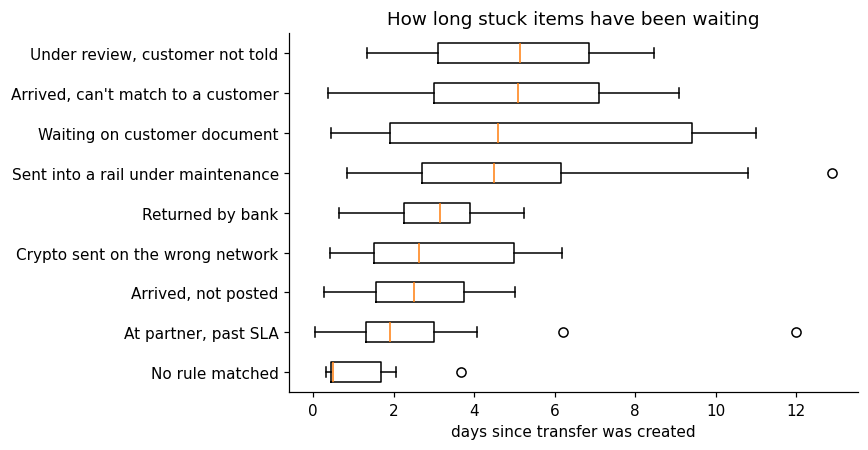

In [10]:
df = pd.read_sql_query("""
    SELECT c.label AS reason, t.age_hours / 24.0 AS age_days
    FROM triage tr JOIN transfers t USING (transfer_id) JOIN causes c USING (cause_id)
    WHERE tr.cause_id <> 'ON_TRACK'
""", con)
order = df.groupby("reason").age_days.median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.boxplot([df[df.reason == r].age_days for r in order], vert=False, tick_labels=list(order))
ax.set_xlabel("days since transfer was created")
ax.set_title("How long stuck items have been waiting")
plt.tight_layout()
fig.savefig("figures/age_by_reason.png")

## Takeaways

1. **Notify on every hold.** Silent compliance holds rank first. The fix is a notification rule, not a policy change.
2. **Reconcile partner settlements against the ledger continuously.** "Arrived, not posted" is invisible without a join across systems.
3. **Block transfers into rails flagged for maintenance.** These items are almost all past SLA, and every one of them was preventable at creation.